In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 9})
from sklearn.model_selection import train_test_split
# Neuroimaging
import ants

In [2]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import ct
import mri

In [3]:
csv_filename = "ADDF_2024_External_MRimage_800.csv"
dicom_dir = f"/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800"
labels_df = pd.read_csv(f"{dicom_dir}/{csv_filename}")
# See convert_kpsc_mri.py to convert dicom to nifti (.dcm to .nii.gz)
nifti_dir = f"/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_nifti"
labels_df["paths"] = labels_df["STUDY_ID"].apply(lambda study_id: [f"{nifti_dir}/{study_id}/T1.nii.gz", f"{nifti_dir}/{study_id}/T2.nii.gz"])
print(labels_df.shape)
labels_df.head()

(800, 16)


,STUDY_ID,YearOfScan,SiteID,AgeOfScan,Sex,RaceETH,idWMD,idWMD_Severity,idCBI,idCBI_Location,Stroke,daysfu_str,Dementia,daysfu_dem,withDiffusion,paths
0,STUDY_0010,2009,3,58,M,Asian and Pacific Islander,1,Mild,0,No,0,344,0,344,0,[/cluster/tufts/hugheslabkp/data_irb_required/...
1,STUDY_0016,2014,11,56,F,White,0,No,0,No,0,1954,0,1954,0,[/cluster/tufts/hugheslabkp/data_irb_required/...
2,STUDY_0018,2016,3,64,F,Hispanic,1,Mild,0,No,0,1390,0,1390,0,[/cluster/tufts/hugheslabkp/data_irb_required/...
3,STUDY_0019,2017,3,82,M,Black,1,Moderate,1,Sub-cortical,1,437,0,918,1,[/cluster/tufts/hugheslabkp/data_irb_required/...
4,STUDY_0020,2017,3,53,M,White,1,Mild,0,No,0,803,0,803,0,[/cluster/tufts/hugheslabkp/data_irb_required/...


(256, 256, 22)


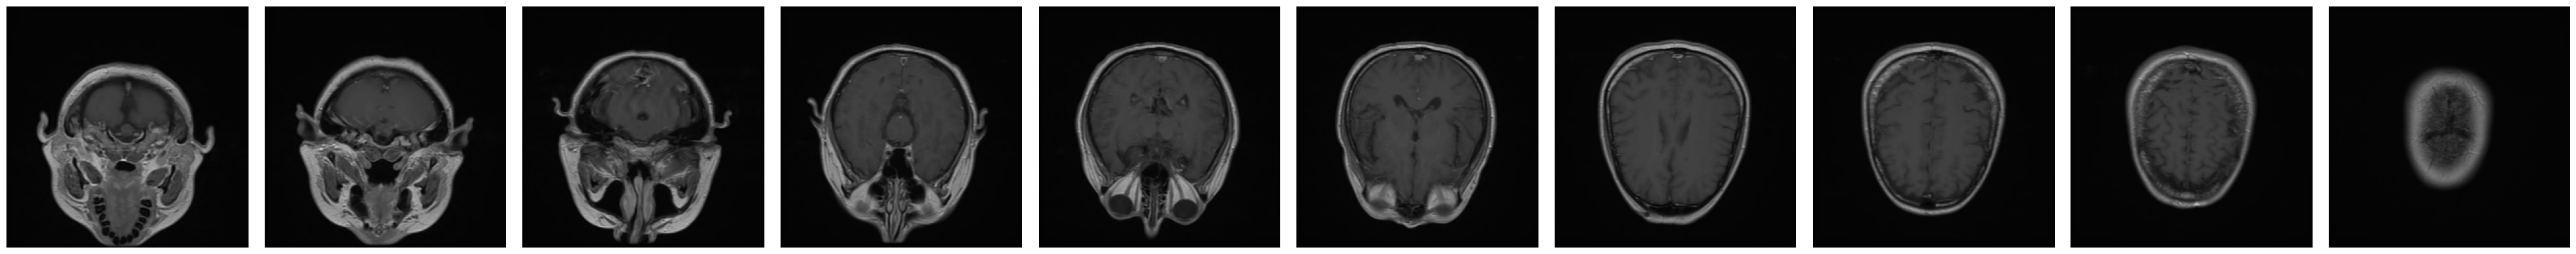

In [5]:
image = ants.image_read(labels_df.iloc[0].paths[0]).numpy()
print(image.shape)
linspace = np.linspace(0, image.shape[-1] - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(np.rot90(image[:,:,j], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image), vmax=np.max(image))
    axs[i].set_axis_off()
    
fig.tight_layout()
plt.show()

In [9]:
csv_filename = "ADDF_2024_External_MRimage_800.csv"
dicom_dir = "/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800"
labels_df = pd.read_csv(f"{dicom_dir}/{csv_filename}")
# See preprocess_kpsc_mri.py to convert nifti to numpy (.nii.gz to .npz)
numpy_dir = "/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy"
labels_df["path"] = labels_df["STUDY_ID"].apply(lambda study_id: f"{numpy_dir}/{study_id}.npz")
labels_df.to_csv(f"{numpy_dir}/labels.csv")
print(labels_df.shape)
labels_df.head()

(800, 16)


,STUDY_ID,YearOfScan,SiteID,AgeOfScan,Sex,RaceETH,idWMD,idWMD_Severity,idCBI,idCBI_Location,Stroke,daysfu_str,Dementia,daysfu_dem,withDiffusion,path
0,STUDY_0010,2009,3,58,M,Asian and Pacific Islander,1,Mild,0,No,0,344,0,344,0,/cluster/tufts/hugheslabkp/data_irb_required/K...
1,STUDY_0016,2014,11,56,F,White,0,No,0,No,0,1954,0,1954,0,/cluster/tufts/hugheslabkp/data_irb_required/K...
2,STUDY_0018,2016,3,64,F,Hispanic,1,Mild,0,No,0,1390,0,1390,0,/cluster/tufts/hugheslabkp/data_irb_required/K...
3,STUDY_0019,2017,3,82,M,Black,1,Moderate,1,Sub-cortical,1,437,0,918,1,/cluster/tufts/hugheslabkp/data_irb_required/K...
4,STUDY_0020,2017,3,53,M,White,1,Mild,0,No,0,803,0,803,0,/cluster/tufts/hugheslabkp/data_irb_required/K...


In [7]:
starts = np.linspace(0, 800, num=11).astype(int)[:-1]
stops = np.linspace(0, 800, num=11).astype(int)[1:]
for start, stop in zip(starts, stops):
    print(f"    'python ../src/preprocess_kpsc_mri.py --csv_filename=\"{csv_filename}\" --dicom_dir=\"{dicom_dir}\" --nifti_dir=\"{nifti_dir}\" --numpy_dir=\"{numpy_dir}\" --start={start} --stop={stop}'")

    'python ../src/preprocess_kpsc_mri.py --csv_filename="ADDF_2024_External_MRimage_800.csv" --dicom_dir="/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800" --nifti_dir="/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_nifti" --numpy_dir="/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy" --start=0 --stop=80'
    'python ../src/preprocess_kpsc_mri.py --csv_filename="ADDF_2024_External_MRimage_800.csv" --dicom_dir="/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800" --nifti_dir="/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_nifti" --numpy_dir="/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy" --start=80 --stop=160'
    'python ../src/preprocess_kpsc_mri.py --csv_filename="ADDF_2024_External_MRimage_800.csv" --dicom_dir="/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800" --nifti_dir="/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_nifti" --numpy_dir="/

(169, 208, 179)


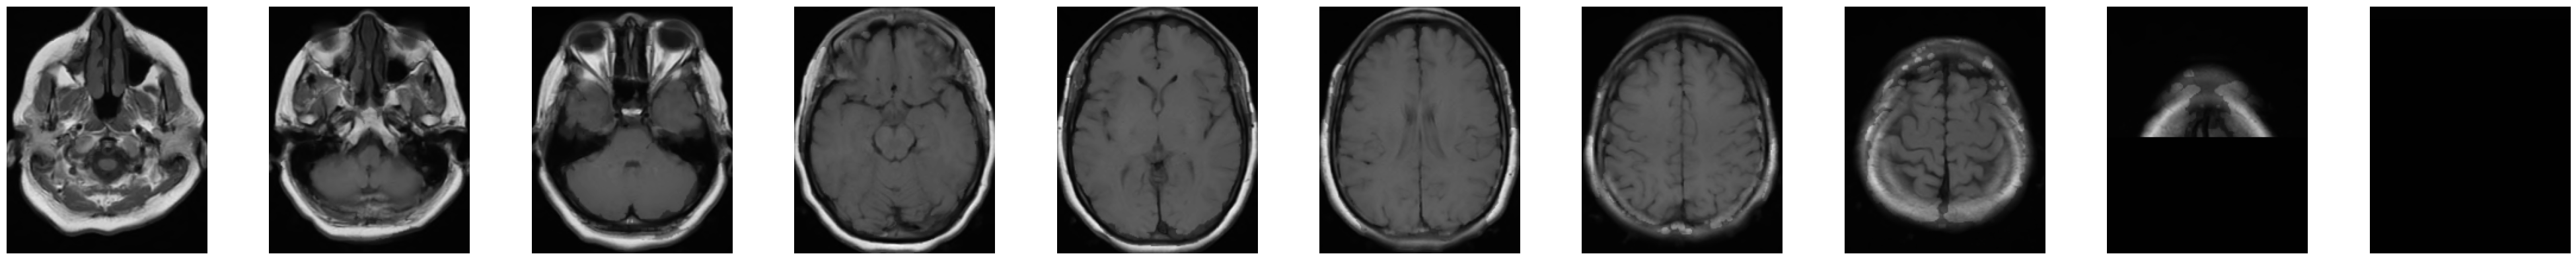

In [18]:
image = np.load(labels_df.iloc[100].path)["arr_0"][0]
print(image.shape)
linspace = np.linspace(0, image.shape[-1] - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(np.rot90(image[:,:,j], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image), vmax=np.max(image))
    axs[i].set_axis_off()
    
fig.tight_layout()
plt.show()

In [5]:
################################################################################
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, embedding_level, 
    experiments_dir, lr, pooling, save, seed, use_pos_embedding, weight_decay
):
    
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = "--embedding_level " if embedding_level else ""
    #instance_conv = "--instance_conv " if instance_conv else ""
    save = "--save " if save else ""
    use_pos_embedding = "--use_pos_embedding " if use_pos_embedding else ""
    
    command = (
        f"python ../src/kpsc.py "
        f"--alpha={alpha} "
        #f"--beta={beta} "
        f"--batch_size={batch_size} "
        f"--criterion=\"{criterion}\" "
        f"--dataset_dir=\"{dataset_dir}\" "
        f"--epochs={epochs} "
        f"{embedding_level}"
        f"--experiments_dir=\"{experiments_dir}\" "
        #f"{instance_conv}"
        #f"--kernel_size={kernel_size} "
        f"--lr={lr} "
        f"--model_name=\"{model_name}\" "
        f"--pooling=\"{pooling}\" "
        f"{save}"
        f"--seed={seed} "
        f"{use_pos_embedding}"
        f"--weight_decay={weight_decay}"
    )
    
    print(f"    \'{command}\'")

In [14]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ["L1"]
dataset_dir = "/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16" 
epochs = 1000
embedding_level = False
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD" 
instance_conv = False
kernel_size = 0
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ["mean"]
save = True
seeds = [1001]
splits = ["test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5",
          "test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9",
          "test_site_ids=2_6_train_site_ids=3_5_8_9_val_site_ids=1_4_7_10_11",
          "test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_11_val_site_ids=2_6",
          "test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_11_val_site_ids=3_8"]
use_pos_embedding = False
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed, split in itertools.product(alphas, criterions, lrs, poolings, seeds, splits):
#for alpha, beta, criterion, delta, lr, pooling, seed in itertools.product(alphas, betas, criterions, deltas, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/{split}"
    temp_experiments_dir = f"{experiments_dir}/{split}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              temp_experiments_dir, lr, pooling, save, seed, use_pos_embedding, weight_decay)

    'python ../src/kpsc.py --alpha=1.0 --batch_size=64 --criterion="L1" --dataset_dir="/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16/test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5" --epochs=1000 --experiments_dir="/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD/test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5" --lr=0.1 --model_name="alpha=1.0_criterion=L1_lr=0.1_pooling=mean_seed=1001" --pooling="mean" --save --seed=1001 --weight_decay=0.0'
    'python ../src/kpsc.py --alpha=1.0 --batch_size=64 --criterion="L1" --dataset_dir="/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16/test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9" --epochs=1000 --experiments_dir="/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD/test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9" --lr=0.1 --model_name="alpha=1.0_criterion=L1_lr=0.1_pooling=mean_s

In [14]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ["L1"]
dataset_dir = "/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16" 
epochs = 1000
embedding_level = False
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI" 
instance_conv = False
kernel_size = 0
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ["mean"]
save = True
seeds = [1001]
splits = ["test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5",
          "test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9",
          "test_site_ids=2_6_train_site_ids=3_5_8_9_val_site_ids=1_4_7_10_11",
          "test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_11_val_site_ids=2_6",
          "test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_11_val_site_ids=3_8"]
use_pos_embedding = False
weight_decay = 0.0

columns = ["model_name", "split", "test_acc", "test_auroc", "test_auprc", "test_loss", "test_nll", "train_acc", "train_auroc", "train_auprc", "train_loss", "train_nll", "val_acc", "val_auroc", "val_auprc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed, split in itertools.product(alphas, criterions, lrs, poolings, seeds, splits):
    
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    
    if os.path.exists(f"{experiments_dir}/{split}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{experiments_dir}/{split}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, split, temp_df.test_acc.values[index], temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_acc.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_acc.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["split"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,split,test_acc,test_auroc,test_auprc,test_loss,test_nll,train_acc,train_auroc,train_auprc,train_loss,train_nll,val_acc,val_auroc,val_auprc,val_loss,val_nll
0,alpha=0.1_criterion=L1_lr=0.001_pooling=mean_s...,test_site_ids=1_4_7_10_11_train_site_ids=2_3_5...,0.781457,0.634052,0.316475,0.849349,0.561857,0.656250,0.682878,0.511349,0.955828,0.631386,0.713450,0.644864,0.418177,0.889012,0.601519
1,alpha=0.1_criterion=L1_lr=0.0001_pooling=mean_...,test_site_ids=2_6_train_site_ids=3_5_8_9_val_s...,0.708075,0.643150,0.422538,0.662490,0.623746,0.642857,0.658181,0.523149,0.688505,0.649208,0.781457,0.656651,0.316969,0.631774,0.593030
2,alpha=0.01_criterion=L1_lr=0.1_pooling=mean_se...,test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_...,0.400000,0.591252,0.403043,1.038995,0.943123,0.727679,0.739644,0.565896,0.646375,0.550105,0.409938,0.692049,0.480357,0.964126,0.868253
3,alpha=0.01_criterion=L1_lr=0.001_pooling=mean_...,test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_...,0.561728,0.653924,0.596782,0.788661,0.745710,0.743304,0.710249,0.470477,0.575837,0.532721,0.670968,0.696078,0.474377,0.642942,0.599991
4,alpha=1e-06_criterion=L1_lr=0.1_pooling=mean_s...,test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_1...,0.573099,0.576949,0.352925,0.812947,0.812883,0.698661,0.751490,0.545184,0.613189,0.613125,0.672840,0.707166,0.610273,0.680192,0.680128


In [13]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")

0.627 +/- 0.070


In [ ]:
# CBI: 0.620 +/- 0.034
# WMD: 0.627 +/- 0.070

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI" 

splits = ["test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5",
          "test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9",
          "test_site_ids=2_6_train_site_ids=3_5_8_9_val_site_ids=1_4_7_10_11",
          "test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_11_val_site_ids=2_6",
          "test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_11_val_site_ids=3_8"]
